<a href="https://colab.research.google.com/github/dlalswns0211/sparta_project_4_team16/blob/main/YJ/COLAB_FD002_BiLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ NASA C-MAPSS FD002 — 딥러닝 RUL 예측 모델링

---

**데이터셋:** NASA C-MAPSS FD002  
**목표:** 항공기 엔진 잔여 수명(RUL) 예측  
**모델:**  BiLSTM   
**평가 지표:** RMSE, NASA Score  
**환경:** Google Colab T4 GPU  

---

## 저장 파일 정의

---

### 📁 preprocessed_FD002/

| 파일명 | 설명 |
|--------|------|
| `FD002_test_RUL.csv` | 원본 `RUL_FD002.txt`를 csv로 변환한 것 (내용 동일). test 데이터의 실제 RUL 정답값. 모델 성능 평가 시 사용 |
| `FD002_scalers_by_cluster.pkl` | 클러스터별 MinMaxScaler 객체 (6개). sub-train 기준으로 클러스터별 fit된 상태. 새 데이터 예측 시 동일한 정규화 적용을 위해 저장 |
| `FD002_kmeans.pkl` | KMeans(k=6) 클러스터링 객체. 새 데이터의 운전 조건 클러스터 예측에 사용 |
| `FD002_op_scaler.pkl` | 운전 조건(setting_1/2/3) MinMaxScaler. KMeans 입력 전처리용 |

---

### 📁 preprocessed_FD002/dl/

| 파일명 | 설명 |
|--------|------|
| `FD002_dl_subtrain_long.csv` | DL 학습용 데이터. train 데이터(208개 엔진)를 전처리 후 슬라이딩 윈도우 적용. Long Format |
| `FD002_dl_valid_long.csv` | DL 검증용 데이터. train 데이터(52개 엔진)를 전처리 후 슬라이딩 윈도우 적용. 학습 중 과적합 모니터링에 사용 |
| `FD002_dl_test_long.csv` | DL 테스트용 데이터. 원본 test 데이터를 전처리 후 엔진별 마지막 20사이클로 슬라이딩 윈도우 적용. 엔진 259개 × 20 = 5180행 |

---

### 📌 Long Format 컬럼 설명

| 컬럼명 | 원래 컬럼명 | 설명 |
|--------|------------|------|
| `sample_id` | `unit_nr` | 슬라이딩 윈도우 단위 고유 ID. 엔진 1개에서 여러 샘플이 생기므로 엔진 번호 대신 윈도우 단위로 구분 |
| `timestep` | `time_cycles` | 윈도우 내 위치 (0~19). 실제 사이클 번호가 아닌 윈도우 안에서 몇 번째 시점인지를 나타냄 |
| `s_1~s_21` | `s_1~s_21` | 상수 센서 1개(s_16) 제거 후 남은 20개 유효 센서 |
| `cluster_0~cluster_5` | `op_cluster` | 운전 조건 원핫인코딩 (6개 컬럼). KMeans k=6 클러스터 레이블을 OHE로 변환 |
| `RUL` | `RUL` | 해당 샘플의 타깃값. 마지막 timestep 기준 RUL이 모든 행에 동일하게 기재됨 (0~125) |

> `setting_1~3`, `unit_nr`, `time_cycles`, `op_cluster` 는 슬라이딩 윈도우 변환 과정에서 제외됨  
> FD002는 운전 조건 6가지를 원핫인코딩(cluster_0~5)으로 변환하여 DL 입력에 포함

---

### 📌 Long Format 구조

| sample_id | timestep | s_1 | s_2 | ... | s_21 | cluster_0 | ... | cluster_5 | RUL |
|-----------|----------|-----|-----|-----|------|-----------|-----|-----------|-----|
| 0 | 0 | ... | ... | ... | ... | 1 | ... | 0 | 125 |
| 0 | 1 | ... | ... | ... | ... | 0 | ... | 1 | 125 |
| ... | ... | ... | ... | ... | ... | ... | ... | ... | ... |
| 0 | 19 | ... | ... | ... | ... | 1 | ... | 0 | 125 |
| 1 | 0 | ... | ... | ... | ... | 0 | ... | 0 | 120 |

- `sample_id`: 윈도우 단위 고유 ID
- `timestep`: 윈도우 내 위치 (0 ~ 19)
- `RUL`: 해당 샘플의 타깃값 (마지막 timestep 기준, 모든 행에 동일하게 기재)

---

### 📌 3D 복원 방법 (모델 입력용)

```python
import numpy as np, pandas as pd

# DL 피처 목록 동적 로드
with open('preprocessed_FD002/FD002_dl_features.txt', 'r') as f:
    DL_FEATURES = [line.strip() for line in f.readlines()]
# 센서 20개 + OHE 6개 = 26개

df  = pd.read_csv('preprocessed_FD002/dl/FD002_dl_subtrain_long.csv')
grp = df.groupby('sample_id')
X   = np.stack([grp.get_group(i)[DL_FEATURES].values
                for i in range(df['sample_id'].nunique())])  # (N, 20, 26)
y   = df.groupby('sample_id')['RUL'].last().values           # (N,)
```

---

### 📌 전처리 파이프라인 요약

```
원본 데이터
├── 상수 센서 제거 (std < 0.01) : 21개 → 20개 (s_16 제거)
├── K-means 클러스터링 (k=6, OP_COLS 기준)
├── RUL 생성 + Clipping (cap=125)
├── 클러스터별 가우시안 필터 (σ=2)
├── Validation 분할 (엔진 단위, 80:20, random_state=42)
├── 클러스터별 MinMax 정규화 (sub-train 기준 fit)
├── 원핫인코딩 (op_cluster → cluster_0~5)
└── 슬라이딩 윈도우 (size=20, step=1) → Long Format CSV 저장
```

## ⚠️ 주의사항
- `run_experiment(...)` 실행 코드는 주석 처리되어 있음
- 실험 실행 시 반드시 **세션 재시작 후 전체 실행** → 원하는 실험만 주석 해제
- AdamW 내부 상태(모멘텀)가 누적되므로 세션 재시작 없으면 실험 결과 오염 가능

# [0] 환경 설정

In [1]:
# 설치 셀 (0번)
!pip install mlflow==2.13.0 pyngrok -q --no-deps
import mlflow

/usr/local/lib/python3.12/dist-packages/mlflow/protos/service_pb2.py:11: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugins which generate code specific to the RPC implementation. service.py will be removed in Jan 2025
  from google.protobuf import service as _service


In [2]:
# 드라이브 마운트 먼저!
from google.colab import drive
drive.mount('/content/drive')
mlflow.set_tracking_uri("sqlite:////content/drive/MyDrive/sparta_project/mlflow.db")
!apt-get -qq install fonts-nanum

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import mlflow
import mlflow.pytorch
import os
import json  # ← CSV 자동 저장 코드에 필요
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')
print(f'PyTorch 버전: {torch.__version__}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
사용 디바이스: cuda
PyTorch 버전: 2.10.0+cu128


# [1] MLflow + ngrok

In [3]:
# import subprocess
# import time

# subprocess.run(['pkill', '-f', 'mlflow'], capture_output=True)
# subprocess.run(['pkill', '-f', 'ngrok'], capture_output=True)
# time.sleep(3)

# process = subprocess.Popen([
#     'mlflow', 'ui',
#     '--port', '5001',
#     '--host', '0.0.0.0',
#     '--backend-store-uri', 'sqlite:////content/drive/MyDrive/sparta_project/mlflow.db'
# ], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# time.sleep(10)

# from pyngrok import ngrok
# ngrok.kill()
# time.sleep(2)
# ngrok.set_auth_token("3ChuPxi4d2fZ5G0g1G18cf5Uhab_7Jx1C9LWPman6JfzZAuMG")
# public_url = ngrok.connect(5001)
# print(f"MLflow UI 주소: {public_url}")

# [2] 데이터 로드 및 3D 복원

In [4]:
BASE_DIR = '/content/drive/MyDrive/sparta_project/preprocessed_FD002'
DATA_DIR = f'{BASE_DIR}/dl'

DL_FEATURES = ['s_1','s_2','s_3','s_4','s_5','s_6','s_7','s_8','s_9','s_10',
                's_11','s_12','s_13','s_14','s_15','s_17','s_18','s_19','s_20','s_21',
                'cluster_0','cluster_1','cluster_2','cluster_3','cluster_4','cluster_5']

subtrain_df = pd.read_csv(f'{DATA_DIR}/FD002_dl_subtrain_long.csv')
valid_df    = pd.read_csv(f'{DATA_DIR}/FD002_dl_valid_long.csv')
test_df     = pd.read_csv(f'{DATA_DIR}/FD002_dl_test_long.csv')
test_rul_df = pd.read_csv(f'{BASE_DIR}/FD002_test_RUL.csv')

def long_to_3d(df):
    grp = df.groupby('sample_id')
    X = np.stack([grp.get_group(i)[DL_FEATURES].values
                  for i in range(df['sample_id'].nunique())])
    y = df.groupby('sample_id')['RUL'].last().values
    return X, y

X_train, y_train = long_to_3d(subtrain_df)
X_valid, y_valid = long_to_3d(valid_df)
X_test,  _       = long_to_3d(test_df)
y_test           = test_rul_df['RUL'].values

print(f'X_train: {X_train.shape} / y_train: {y_train.shape}')
print(f'X_valid: {X_valid.shape} / y_valid: {y_valid.shape}')
print(f'X_test:  {X_test.shape}  / y_test:  {y_test.shape}')

X_train: (39512, 20, 26) / y_train: (39512,)
X_valid: (9307, 20, 26) / y_valid: (9307,)
X_test:  (259, 20, 26)  / y_test:  (259,)


# [3] Dataset / DataLoader

In [5]:
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 256  # FD001: 64 → FD002: 256

train_dataset = RULDataset(X_train, y_train)
valid_dataset = RULDataset(X_valid, y_valid)
test_dataset  = RULDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# [4] 평가 함수

In [6]:
def nasa_score(y_true, y_pred):
    diff = y_pred - y_true
    score = np.sum(np.where(diff < 0,
                            np.exp(-diff / 13) - 1,
                            np.exp(diff / 10) - 1))
    return score

def evaluate(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            pad_mask = (X_batch.sum(dim=-1) == 0)  # zero-padding 마스킹
            out = model(X_batch, src_key_padding_mask=pad_mask).cpu().numpy()
            preds.extend(out)
            targets.extend(y_batch.numpy())
    preds   = np.array(preds)
    targets = np.array(targets)
    rmse  = np.sqrt(np.mean((preds - targets) ** 2))
    score = nasa_score(targets, preds)
    return rmse, score, preds, targets

# [5] 학습 함수

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pad_mask = (X_batch.sum(dim=-1) == 0)  # zero-padding 마스킹
        optimizer.zero_grad()
        pred = model(X_batch, src_key_padding_mask=pad_mask)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient Clipping
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)

# [6] 시각화 함수

In [8]:
def plot_results(exp_name, model_name, train_loss_list, val_rmse_list,
                 test_preds, test_targets):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{model_name} - {exp_name} (FD002)', fontsize=14, fontweight='bold')  # ← FD002 추가

    ax = axes[0]
    ax.plot(train_loss_list, label='Train Loss')
    ax.plot(val_rmse_list,   label='Val RMSE')
    ax.set_title('학습 곡선')
    ax.set_xlabel('Epoch')
    ax.legend()

    ax = axes[1]
    ax.scatter(test_targets, test_preds, alpha=0.5, s=20)
    max_val = max(test_targets.max(), test_preds.max())
    ax.plot([0, max_val], [0, max_val], 'r--', label='이상적 예측')
    ax.set_title('예측값 vs 실제값 (Test)')
    ax.set_xlabel('실제 RUL')
    ax.set_ylabel('예측 RUL')
    ax.legend()

    ax = axes[2]
    residuals = test_preds - test_targets
    ax.hist(residuals, bins=20, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', label='잔차=0')
    ax.set_title('잔차 분포 (Test)')
    ax.set_xlabel('예측 - 실제')
    ax.set_ylabel('빈도')
    ax.legend()

    plt.tight_layout()
    plt.show()

# [7] 모델 정의

In [9]:
class BiLSTMModel(nn.Module):
    def __init__(self, input_size=26, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x, src_key_padding_mask=None):
        if src_key_padding_mask is not None:
            lengths = (~src_key_padding_mask).sum(dim=1).clamp(min=1).cpu()
            packed = nn.utils.rnn.pack_padded_sequence(
                x, lengths, batch_first=True, enforce_sorted=False)
            _, (hn, _) = self.bilstm(packed)
        else:
            _, (hn, _) = self.bilstm(x)
        # 양방향: 마지막 레이어 forward + backward concat
        out = self.dropout(torch.cat([hn[-2], hn[-1]], dim=-1))
        return self.fc(out).squeeze(1)

# [8] 실험 함수


In [10]:
EPOCHS   = 100
LR       = 1e-3
PATIENCE = 20

def run_experiment(exp_name, model_class, hidden_size=64, num_layers=2, dropout=0.2):
    exp_name_full = f"{model_class.__name__}_FD002"
    mlflow.set_experiment(exp_name_full)

    with mlflow.start_run(run_name=exp_name):
        mlflow.log_params({
            "model":        model_class.__name__,
            "hidden_size":  hidden_size,
            "num_layers":   num_layers,
            "dropout":      dropout,
            "batch_size":   BATCH_SIZE,
            "lr":           LR,
            "epochs":       EPOCHS,
            "dataset":      "FD002",
            "optimizer":    "AdamW",
            "weight_decay": 1e-4,
            "scheduler":    "ReduceLROnPlateau",
            "loss":         "HuberLoss_delta10",
            "window_size":  20,
        })

        model = model_class(
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
        criterion = nn.HuberLoss(delta=10.0)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

        best_val_rmse = float('inf')
        patience_cnt  = 0
        train_loss_list = []
        val_rmse_list   = []

        for epoch in range(1, EPOCHS + 1):
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
            val_rmse, val_score, _, _ = evaluate(model, valid_loader, device)

            scheduler.step(val_rmse)

            train_loss_list.append(train_loss)
            val_rmse_list.append(val_rmse)

            mlflow.log_metrics({
                "train_loss": train_loss,
                "val_rmse":   val_rmse,
                "val_score":  val_score,
                "lr":         optimizer.param_groups[0]['lr']
            }, step=epoch)

            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_state    = model.state_dict().copy()
                patience_cnt  = 0
            else:
                patience_cnt += 1

            if epoch % 10 == 0:
                print(f"Epoch {epoch:3d} | train_loss: {train_loss:.4f} | val_rmse: {val_rmse:.4f} | lr: {optimizer.param_groups[0]['lr']:.6f}")

            if patience_cnt >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

        model.load_state_dict(best_state)
        test_rmse, test_score, test_preds, test_targets = evaluate(model, test_loader, device)

        mlflow.log_metrics({"test_rmse": test_rmse, "test_score": test_score})
        mlflow.pytorch.log_model(model, "model")

        # ── CSV 자동 저장 ──────────────────────────────────────────
        BEST_DIR = '/content/drive/MyDrive/sparta_project/best_results'
        os.makedirs(BEST_DIR, exist_ok=True)

        MODEL_NAME = model_class.__name__
        best_meta_path = f'{BEST_DIR}/FD002_{MODEL_NAME}_best.json'

        if os.path.exists(best_meta_path):
            with open(best_meta_path) as f:
                prev_best = json.load(f)
            prev_rmse = prev_best['test_rmse']
        else:
            prev_rmse = float('inf')

        if test_rmse < prev_rmse:
            pd.DataFrame({
                'engine_id':     range(len(test_preds)),
                'actual_rul':    test_targets,
                'predicted_rul': test_preds
            }).to_csv(f'{BEST_DIR}/FD002_{MODEL_NAME}_pred.csv', index=False)

            with open(best_meta_path, 'w') as f:
                json.dump({
                    'exp_name':   exp_name,
                    'model':      MODEL_NAME,
                    'dataset':    'FD002',
                    'test_rmse':  float(test_rmse),
                    'nasa_score': float(test_score)
                }, f, indent=2)

            print(f"🏆 최고 성능 갱신! RMSE: {test_rmse:.4f} → 드라이브 저장 완료")
        else:
            print(f"📊 현재 RMSE: {test_rmse:.4f} | 기존 최고: {prev_rmse:.4f} → 저장 안함")
        # ───────────────────────────────────────────────────────────

        print(f"\n{'='*40}")
        print(f"[{exp_name}] 최종 결과")
        print(f"  Test RMSE  : {test_rmse:.4f}")
        print(f"  NASA Score : {test_score:.2f}")
        print(f"{'='*40}")

        plot_results(
            exp_name        = exp_name,
            model_name      = model_class.__name__,
            train_loss_list = train_loss_list,
            val_rmse_list   = val_rmse_list,
            test_preds      = test_preds,
            test_targets    = test_targets
        )

        return test_rmse, test_score

# [9] 실험 실행 셀
실험 순서는 무조건 B-1 → H-5 → H-6 → H-3 → H-4 → H-1 → H-2

층수가 많으면 오래 걸림

2026/04/28 12:24:05 INFO mlflow.tracking.fluent: Experiment with name 'BiLSTMModel_FD002' does not exist. Creating a new experiment.


Epoch  10 | train_loss: 145.6464 | val_rmse: 20.1970 | lr: 0.001000
Epoch  20 | train_loss: 62.1525 | val_rmse: 13.4461 | lr: 0.001000
Epoch  30 | train_loss: 56.5171 | val_rmse: 13.9875 | lr: 0.001000
Epoch  40 | train_loss: 50.0625 | val_rmse: 12.8043 | lr: 0.000250


2026/04/28 12:25:34 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Early stopping at epoch 47


2026/04/28 12:25:42 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏆 최고 성능 갱신! RMSE: 26.5667 → 드라이브 저장 완료

[B-1] 최종 결과
  Test RMSE  : 26.5667
  NASA Score : 6485.46


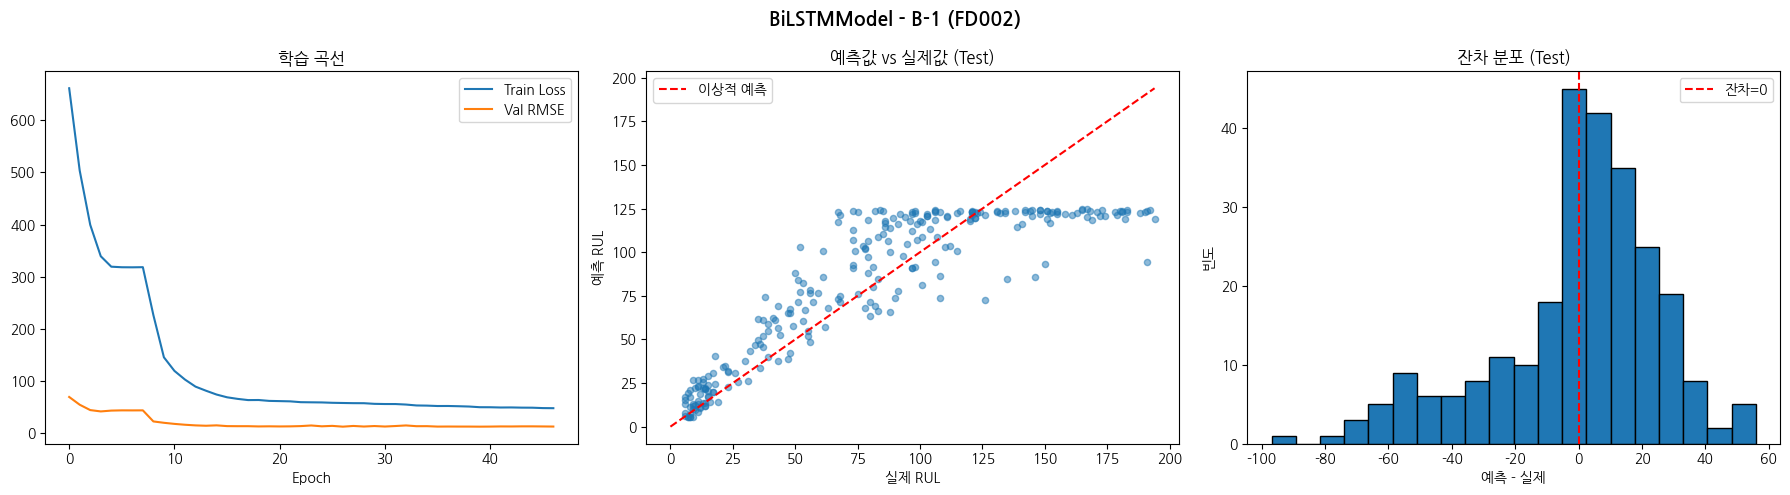

(np.float32(26.566748), np.float32(6485.461))

In [12]:
# 베이스라인
run_experiment("B-1", BiLSTMModel, hidden_size=64, num_layers=2, dropout=0.2)

# 하이퍼파라미터 실험
# H-1: 층수 3
# run_experiment("H-1", BiLSTMModel, hidden_size=64, num_layers=3, dropout=0.2)

# H-2: 층수 4
# run_experiment("H-2", BiLSTMModel, hidden_size=64, num_layers=4, dropout=0.2)

# H-3: 은닉층 128
# run_experiment("H-3", BiLSTMModel, hidden_size=128, num_layers=2, dropout=0.2)

# H-4: 은닉층 256
# run_experiment("H-4", BiLSTMModel, hidden_size=256, num_layers=2, dropout=0.2)

# H-5: 드롭아웃 0.3
# run_experiment("H-5", BiLSTMModel, hidden_size=64, num_layers=2, dropout=0.3)

# H-6: 드롭아웃 0.5
# run_experiment("H-6", BiLSTMModel, hidden_size=64, num_layers=2, dropout=0.5)